In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

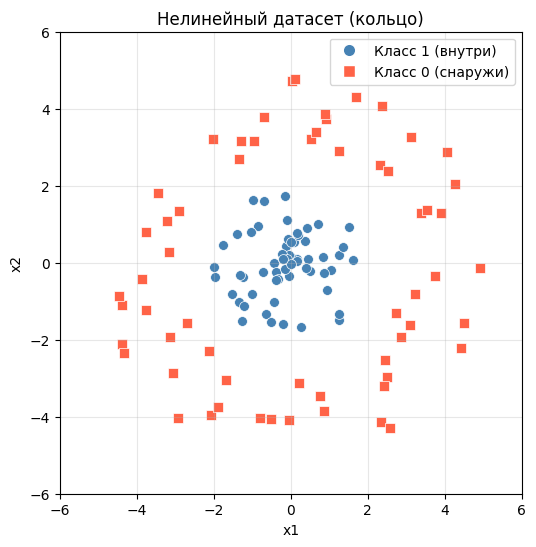

In [2]:
random.seed(42)
n_per_class = 60

data = []

# Класс 1 — внутренний круг (радиус 0..2)
for _ in range(n_per_class):
    r     = random.uniform(0, 2)
    angle = random.uniform(0, 2 * math.pi)
    x1    = r * math.cos(angle)
    x2    = r * math.sin(angle)
    data.append((x1, x2, 1))

# Класс 0 — внешнее кольцо (радиус 3..5)
for _ in range(n_per_class):
    r     = random.uniform(3, 5)
    angle = random.uniform(0, 2 * math.pi)
    x1    = r * math.cos(angle)
    x2    = r * math.sin(angle)
    data.append((x1, x2, 0))

features = [(x1, x2) for x1, x2, _ in data]
labels   = [label for _, _, label in data]

# Визуализация датасета
plt.figure(figsize=(6, 6))
for (x1, x2), label in zip(features, labels):
    color  = 'steelblue' if label == 1 else 'tomato'
    marker = 'o'         if label == 1 else 's'
    plt.scatter(x1, x2, color=color, marker=marker, s=50, edgecolors='white', linewidths=0.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Класс 1 (внутри)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Класс 0 (снаружи)'),
]
plt.legend(handles=legend_elements)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Нелинейный датасет (кольцо)')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
def plot_decision_boundary(predict_fn, title='Граница решения'):
    """
    Визуализирует границу решения нейронной сети.

    predict_fn — функция (X: np.ndarray shape [N, 2]) -> np.ndarray shape [N]
                 Принимает батч точек и возвращает вероятность/класс для каждой.
    """
    h = 0.12  # шаг сетки

    x1_vals = np.arange(-6, 6 + h, h)
    x2_vals = np.arange(-6, 6 + h, h)
    xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

    # Батчевый вызов — один predict на всю сетку вместо ~10 000 отдельных
    points = np.column_stack([xx1.ravel(), xx2.ravel()])
    Z = predict_fn(points).reshape(xx1.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx1, xx2, Z, alpha=0.35, levels=1, colors=['tomato', 'steelblue'])
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='purple', linewidths=2)

    for (x1, x2), label in zip(features, labels):
        color  = 'steelblue' if label == 1 else 'tomato'
        marker = 'o'         if label == 1 else 's'
        plt.scatter(x1, x2, color=color, marker=marker, s=50,
                    edgecolors='white', linewidths=0.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Класс 1'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Класс 0'),
        Line2D([0], [0], color='purple', linewidth=2, label='Граница решения'),
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

In [4]:
import keras

In [5]:
X = np.array([np.array(i) for i in features])
Y = labels
X[:5], Y[:5]

(array([[ 1.26309526,  0.20014214],
        [ 0.09215033,  0.54228481],
        [-0.65464994, -1.31946688],
        [ 1.5246941 ,  0.92695491],
        [ 0.82909764,  0.1570643 ]]),
 [1, 1, 1, 1, 1])

In [6]:
categorized_y = keras.utils.to_categorical(Y)
categorized_y[:5]

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [16]:
model = keras.models.Sequential()
model.add(keras.layers.Dense(3, activation='relu', input_shape=(2,)))
model.add(keras.layers.Dropout(.1))
# model.add(keras.layers.Dense(1, activation='relu', input_shape=(2,)))
# model.add(keras.layers.Dropout(.1))
model.add(keras.layers.Dense(2, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.fit(X, categorized_y, epochs=100, batch_size=10, verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4750 - loss: 0.8454  
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.8467
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5250 - loss: 0.8434
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5333 - loss: 0.8135
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - accuracy: 0.5000 - loss: 0.8160
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5583 - loss: 0.7927
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5583 - loss: 0.7603
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.5583 - loss: 0.7368
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - accuracy: 0.5917 - loss: 0.7172
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.6500 - loss: 0.7186
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6583 - loss: 0.6936
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step -

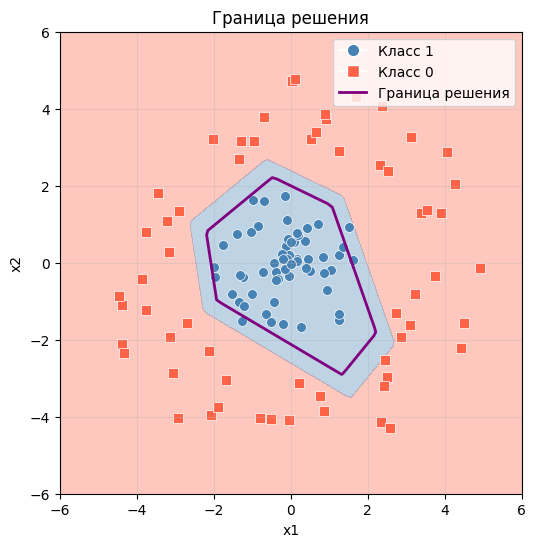

In [18]:
def predict_fn(X):
    # X — массив точек shape [N, 2]
    # model.predict возвращает [N, 2] (softmax по двум классам)
    # берём вероятность класса 1 (второй столбец)
    preds = model.predict(X, verbose=0)
    return preds[:, 1]

plot_decision_boundary(predict_fn=predict_fn)